# Crimson-Hour — a quantitative teardown 🔬
### Mechanical/forecast decomposition · two-proportion + Fisher increment · Wilson + beta-binomial on 22/25 · forking-paths Monte-Carlo · cost-swept afternoon short

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![88% predictive?: Inflated](https://img.shields.io/badge/88%25_predictive%3F-Inflated-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* The edgeful confluence is a **real but modest intraday-continuation effect (~+6 pp on the *forecastable* leg)** wrapped in a **mechanical head-start (~75% of the headline lift)** and inflated by small-sample selection to an 88–90% headline — while the IB-rejection term adds nothing over the opening candle's sign.

> ⚠️ **Not investment advice.** Executed on the synthetic tape (baked-in momentum 0.12, null IB flag) where the decomposition recovers what we put in; the real verdict is quoted from [`../docs/results.md`](../docs/results.md) (`examples/verify.py`), with the literature map in [`../docs/references.md`](../docs/references.md). Fixed seeds; no network.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (crimson_hour/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from crimson_hour import data, signals, decompose

# Offline synthetic tape: sessions with a KNOWN afternoon momentum (0.12) and an IB-rejection
# flag drawn INDEPENDENTLY of the close -- so the decomposition has a ground truth to recover.
# The real verdict (SPY/QQQ + ES/NQ) is in ../docs/results.md via examples/verify.py.
feat, truth = data.synthetic_sessions(seed=0)
print(f"{len(feat)} synthetic sessions | baked-in momentum {truth.momentum} | "
      f"baseline red {truth.baseline_red:.1%} | IB flag null = {truth.ib_is_null}")


520 synthetic sessions | baked-in momentum 0.12 | baseline red 45.0% | IB flag null = True


## 1 · The claim, decomposed

Let `r₁` be the opening-candle return (9:30→10:30) and `r₂` the rest-of-day return (10:30→16:00). The session closes red iff `r₁ + r₂ < 0` (in log space). The pitch quotes **P(r₁+r₂ < 0 | r₁ < 0 ∧ IB-rejected)**. Decompose it:

- **Mechanical:** conditioning on `r₁ < 0` already puts the day below its open; P(session red | r₁<0) is high largely because `r₂` must *overcome* `|r₁|`, not because `r₂` is forecast.
- **Forecast:** the only genuinely predictive quantity at 10:30 is **P(r₂ < 0 | r₁ < 0)** vs its baseline P(r₂ < 0) — intraday return continuation.
- **Increment:** does the IB-rejection event `1[argmax_t high < argmin_t low]` shift the close-rate *given* `r₁ < 0`? H₀: it is conditionally independent of `r₂`.

The synthetic bakes exactly this: `r₂ = β·r₁ + ε` with β = 0.12 (real continuation) and an IB flag drawn independently of `(r₁ magnitude, r₂)` — so the increment's true value is 0.

In [2]:
m = signals.condition_masks(feat)
tab = decompose.conditional_table(m, signals.session_red(feat))
display(tab.round(4))

,k,n,rate,wilson_low,wilson_high,lift_pp
baseline,234,520,0.4500,0.4078,0.4930,0.0000
oc_red,172,240,0.7167,0.6566,0.7699,26.6667
oc_green,62,280,0.2214,0.1767,0.2736,-22.8571
ib_rejected,126,248,0.5081,0.4462,0.5697,5.8065
ib_not_rejected,108,272,0.3971,0.3407,0.4563,-5.2941
confluence (oc_red & ib_rej),91,120,0.7583,0.6745,0.8261,30.8333
oc_red & ib_NOT_rej,81,120,0.6750,0.5869,0.7522,22.5000


## 3–4 · The mechanical/forecast split — the load-bearing number

`mechanical_vs_predictive` reports the headline conditional, the continuation conditional, both baselines, and the share of the headline lift that is the head-start. On the synthetic the split is recovered; on the real tape it is the verdict.

In [3]:
s = decompose.mechanical_vs_predictive(feat)
for k, v in s.items():
    print(f'  {k:>22}: {v:.4f}' if isinstance(v, float) else f'  {k:>22}: {v}')

           headline_rate: 0.7167
       headline_baseline: 0.4500
        headline_lift_pp: 26.6667
       continuation_rate: 0.5083
   continuation_baseline: 0.4962
    continuation_lift_pp: 1.2179
      mechanical_lift_pp: 25.4487
        mechanical_share: 0.9543
                n_oc_red: 240


> **Real tape** (../docs/results.md): SPY headline P(session red | OC-red) **68.9%** (lift +23.1 pp) collapses to continuation **50.9%** (lift +6.7 pp) — **71%** mechanical. QQQ: **72.1%** → **49.0%**, **79%** mechanical. The forecastable continuation edge is ~+6 pp on ~700 sessions: small, real, and an order of magnitude below the headline.

## 4d · Is the continuation *signal* real? (separate from tradable)

`continuation_test` contrasts the afternoon after OC-red vs OC-green, on the sign (two-proportion z) and the mean return (Welch t). This is the small, true core — intraday return continuation — and it must be judged *before* asking if it pays.

In [4]:
ct = decompose.continuation_test(feat)
print({k:(round(v,4) if isinstance(v,float) else v) for k,v in ct.items()})

{'rest_red_oc_red': 0.5083, 'rest_red_oc_green': 0.4857, 'sign_diff_pp': 2.2619, 'sign_z': 0.5143, 'sign_p_value': 0.6071, 'mean_rest_oc_red_bps': 0.2169, 'mean_rest_oc_green_bps': 4.3586, 'mean_diff_bps': -4.1417, 'mean_t': -0.7922, 'mean_p_value': 0.4283, 'n_oc_red': 240, 'n_oc_green': 280}


> **Real tape:** the afternoon is genuinely lower after a red morning — SPY mean rest_ret **-2.19 bps** (OC-red) vs **+5.60 bps** (OC-green), sign contrast z p = **0.001** (mean-contrast Welch p = 0.121, marginal); QQQ **-3.70 bps** vs **+9.05 bps**, sign p = **0.003**, mean p = **0.041**. The morning carries real directional information into the afternoon. Whether you can *bank* it is beat 6.

## 4 · Does IB-rejection add anything over OC-red?

Two-proportion z and Fisher exact on (OC-red ∧ IB-rejected) vs (OC-red ∧ ¬rejected). Under the synthetic null the increment is ~0 and non-significant.

In [5]:
inc = decompose.ib_increment(feat)
print({k: (round(v,4) if isinstance(v,float) else v) for k,v in inc.items()})

{'confluence_rate': 0.7583, 'confluence_k': 91, 'confluence_n': 120, 'control_rate': 0.675, 'control_k': 81, 'control_n': 120, 'increment_pp': 8.3333, 'z': 1.4325, 'z_p_value': 0.152, 'fisher_p_value': 0.1971}


> **Real tape:** the OC-red-not-rejected control is *tiny* (ES n=6, NQ n=1 in the 60-day 5-minute window — itself a small-sample warning), and the increment is statistically nothing (ES Fisher p = **0.62**, NQ p = **1.00**). The second signal is redundant given the first — as it must be if both are just reading 'the morning was weak.'

## 4b · Small-sample honesty — Wilson and the beta-binomial on 22/25

The quoted 88% is `k/n = 22/25`. The textbook normal interval is invalid near 1.0 and at n=25; the Wilson score interval and a Beta(1,1) posterior are not. Both say the same thing: the point is near the top of a wide band.

In [6]:
for (k,n,label) in [(22,25,'ES 88%'), (28,31,'NQ 90%')]:
    lo,hi = decompose.wilson_ci(k,n)
    post = decompose.beta_binomial(k,n, thresholds=(0.7,0.6))
    print(f'{label}: {k}/{n}={k/n:.1%}  Wilson95 [{lo:.1%},{hi:.1%}]  '
          f"post.mean {post['posterior_mean']:.1%} cred95 [{post['cred_low']:.1%},{post['cred_high']:.1%}]  "
          f"P(rate>70%)={post['P(rate>0.7)']:.0%}")

ES 88%: 22/25=88.0%  Wilson95 [70.0%,95.8%]  post.mean 85.2% cred95 [69.8%,95.6%]  P(rate>70%)=97%
NQ 90%: 28/31=90.3%  Wilson95 [75.1%,96.7%]  post.mean 87.9% cred95 [75.0%,96.5%]  P(rate>70%)=99%


## 4c · The garden of forking paths — "one prompt, combine the reports"

The dashboard was built by combining reports until a confluence stood out. That is multiple comparisons. Model it: `n_candidates` confluences, each selecting ~25 sessions whose *true* close-red rate is the realistic ~70% from the high-power leg; quote the **max** observed rate. `mining_inflation` returns its distribution.

{'p_true': 0.705, 'n_cond': 25, 'n_candidates': 12, 'expected_best_rate': 0.8465, 'best_rate_p95': 0.92, 'inflation_pp': 14.1464, 'observed': 0.88, 'P(best>=observed)': 0.3629}


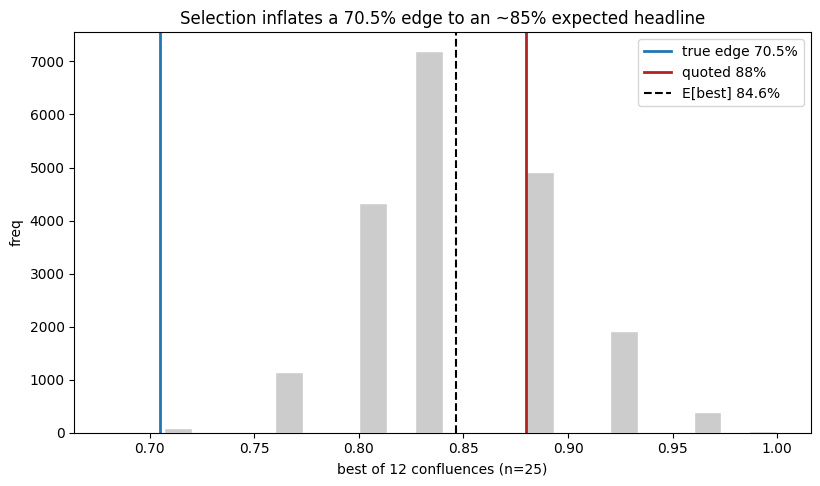

In [7]:
mining = decompose.mining_inflation(p_true=0.705, n_cond=25, n_candidates=12,
                                    observed=0.88, seed=0)
print({k:(round(v,4) if isinstance(v,float) else v) for k,v in mining.items()})
# distribution
rng = np.random.default_rng(0)
best = (rng.binomial(25, 0.705, size=(20000,12))/25).max(axis=1)
plt.hist(best, bins=24, color='#cccccc', edgecolor='white')
plt.axvline(0.705, color='#1f77b4', lw=2, label='true edge 70.5%')
plt.axvline(0.88, color='#b22222', lw=2, label='quoted 88%')
plt.axvline(best.mean(), color='k', ls='--', lw=1.5, label=f'E[best] {best.mean():.1%}')
plt.xlabel('best of 12 confluences (n=25)'); plt.ylabel('freq'); plt.legend()
plt.title('Selection inflates a 70.5% edge to an ~85% expected headline'); plt.show()

> A true **70.5%** edge mined this way *expects* a best of **84.6%** (95th pct **92.0%**), and clears the published 88% **36.2%** of the time. The headline is the expected output of the search, not evidence against the null. (frank's own pre-NFP dashboard returning 64% ≈ baseline is the same machine's un-published draw.)

## 5 · The verdict, with the numbers

**Signal `WEAK`** — genuine continuation lift only **+6.7 pp** / **+5.6 pp** (SPY/QQQ, ~700 sessions); **71%–79%%** of the headline is a mechanical head-start; IB-rejection increment ≈ 0 (Fisher p 0.62/1.00). **Tradability `MIRAGE`** — the afternoon short that monetises the continuation grosses +2.19 bps/+3.70 bps at Sharpe +0.40/+0.54 with a *t* of only +0.68/+0.91 (noise), and its 2.19 bps/3.70 bps break-even sits inside real costs (net Sharpe +0.03/+0.25 at 2 bps). **"88% predictive?" `INFLATED`** — a small-sample, selection-maximised draw from a ~70.5% true rate (E[best of 12]≈84.6%). Real numbers as-of 2026-06-01 in [`../docs/results.md`](../docs/results.md).

## 6 · Could you trade it — the afternoon short, cost-swept

The only positive-expectancy expression is to trade the continuation: short 10:30→close on OC-red days (pnl = −rest_ret). We run it and sweep the round-trip cost.

{'n_trades': 240, 'trades_per_year': 116.3077, 'gross_mean_bps': -0.2169, 'gross_t': -0.0589, 'gross_sharpe': -0.041, 'win_rate': 0.5083, 'break_even_cost_bps': -0.2169}
net Sharpe by cost: {0.0: -0.041, 0.5: -0.135, 1.0: -0.23, 2.0: -0.419, 5.0: -0.985}


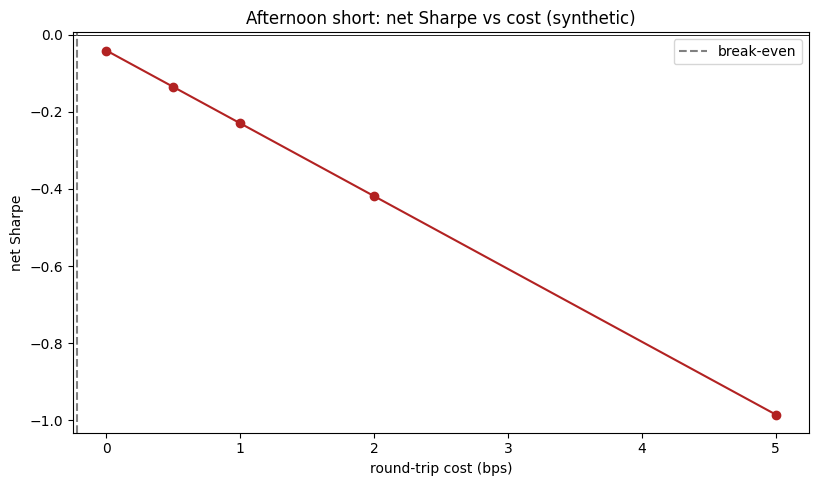

In [8]:
bt = decompose.afternoon_short_backtest(feat)
print({k:(round(v,4) if isinstance(v,float) else v) for k,v in bt.items() if k!='net'})
costs = [0.0,0.5,1.0,2.0,5.0]
print('net Sharpe by cost:', {c: round(bt['net'][c]['net_sharpe'],3) for c in costs})
plt.plot(costs, [bt['net'][c]['net_sharpe'] for c in costs], 'o-', color='#b22222')
plt.axhline(0, color='k', lw=0.6)
plt.axvline(bt['break_even_cost_bps'], color='grey', ls='--', label='break-even')
plt.xlabel('round-trip cost (bps)'); plt.ylabel('net Sharpe'); plt.legend()
plt.title('Afternoon short: net Sharpe vs cost (synthetic)'); plt.show()

> **Real tape:** the afternoon short earns a gross **+2.19 bps/trade** on SPY (**+3.70 bps** QQQ) at a gross Sharpe of only **+0.40** / **+0.54** — and its own *t*-stat is **+0.68** / **+0.91**, i.e. the tradable expectancy is **not distinguishable from zero**. Break-even round-trip cost is **2.19 bps** / **3.70 bps**, which a realistic two-leg intraday round-trip (spread + slippage + imperfect close fill) meets; at 2 bps the net Sharpe is **+0.03** (SPY) / **+0.25** (QQQ). Capacity is irrelevant — the binding constraint is that the gross edge is noise (t < 1) and the break-even is below real costs. A real *signal*, an untradable *trade*.

## 7 · Going further

- **Cost sweep on the continuation leg** — break-even spread for the 10:30→close short; pre-registered expectation: below realistic costs.
- **Regime map** — the conditional rate across rolling windows; the baseline red rate alone moved 46%→33% between the quoted window and our recent 60-day futures sample.
- **Magnitude conditioning** — does a *bigger* red hour forecast more continuation, or just a bigger head-start? Separate the two with a continuation regression on `r₁`.
- **The mining audit** — re-run the dashboard's report-combination over a held-out year and count how many "confluences" clear 80%; compare to the null.

Engine: [`../../../quantlab/`](../../../quantlab/). Method: [`METHODOLOGY.md`](../../../METHODOLOGY.md). Real run: `examples/verify.py` → [`../docs/results.md`](../docs/results.md). Literature: [`../docs/references.md`](../docs/references.md).